In [25]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [12]:
results_path = "../results"
df5 = pd.read_csv(f'{results_path}/5_multi_bound.csv')
df10 = pd.read_csv(f'{results_path}/10_multi_bound.csv')
df20 = pd.read_csv(f'{results_path}/20_multi_bound.csv')
df50 = pd.read_csv(f'{results_path}/50_multi_bound.csv')

df = pd.concat([df5, df10, df20, df50], ignore_index=True)

In [18]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Split dataset markers
df_greedy = df[df['planner_type'] == 'greedy']
df_mb = df[df['planner_type'] == 'multi_bound']

# Create a consistent color palette across all heuristics
unique_heuristics = df['heuristic'].unique()
palette = sns.color_palette("Set2", len(unique_heuristics))
heuristic_colors = dict(zip(unique_heuristics, palette))

# Helper function to auto-label bar heights using version-safe formatting
def autolabel_bars(ax, format_str="%.1f"):
    """Iterates over bar containers to place numerical values above the bars."""
    for container in ax.containers:
        # Using %-style formatting (e.g., '%.1f' or '%.2f') works across all versions
        ax.bar_label(container, fmt=format_str, padding=3, fontsize=9)

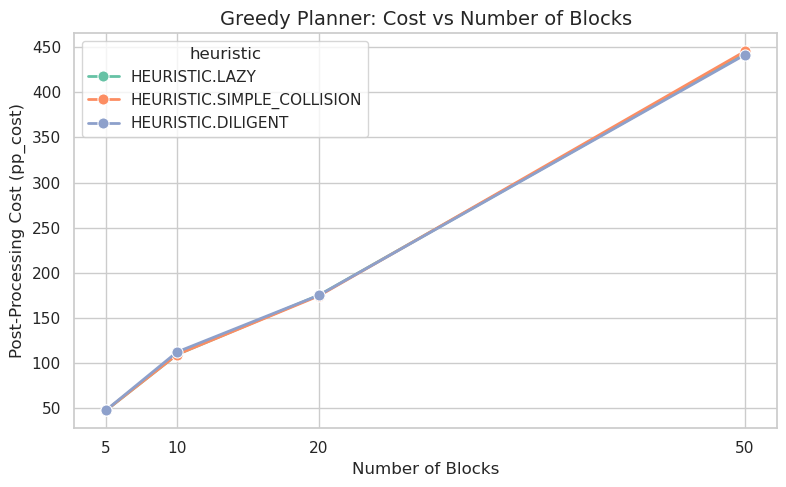

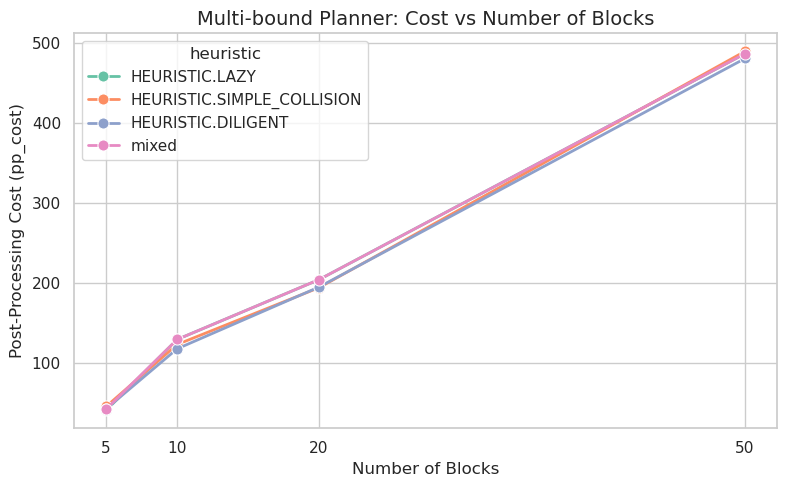

In [24]:
# 1. Line plots for cost vs number of blocks
# Greedy Planner
df_greedy = df[df['planner_type'] == 'greedy'].sort_values('no.blocks')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_greedy,
             x='no.blocks',
             y='pp_cost',
             hue='heuristic',
             palette=heuristic_colors,
             marker='o',
             ax=ax,
             linewidth=2,
             markersize=8)
ax.set_title('Greedy Planner: Cost vs Number of Blocks', fontsize=14)
ax.set_xlabel('Number of Blocks', fontsize=12)
ax.set_ylabel('Post-Processing Cost (pp_cost)', fontsize=12)
ax.set_xticks([5, 10, 20, 50])
plt.tight_layout()

# Multi-bound Planner
df_mb = df[df['planner_type'] == 'multi_bound'].sort_values('no.blocks')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_mb,
             x='no.blocks',
             y='pp_cost',
             hue='heuristic',
             palette=heuristic_colors,
             marker='o',
             ax=ax,
             linewidth=2,
             markersize=8)
ax.set_title('Multi-bound Planner: Cost vs Number of Blocks', fontsize=14)
ax.set_xlabel('Number of Blocks', fontsize=12)
ax.set_ylabel('Post-Processing Cost (pp_cost)', fontsize=12)
ax.set_xticks([5, 10, 20, 50])
plt.tight_layout()
plt.show()

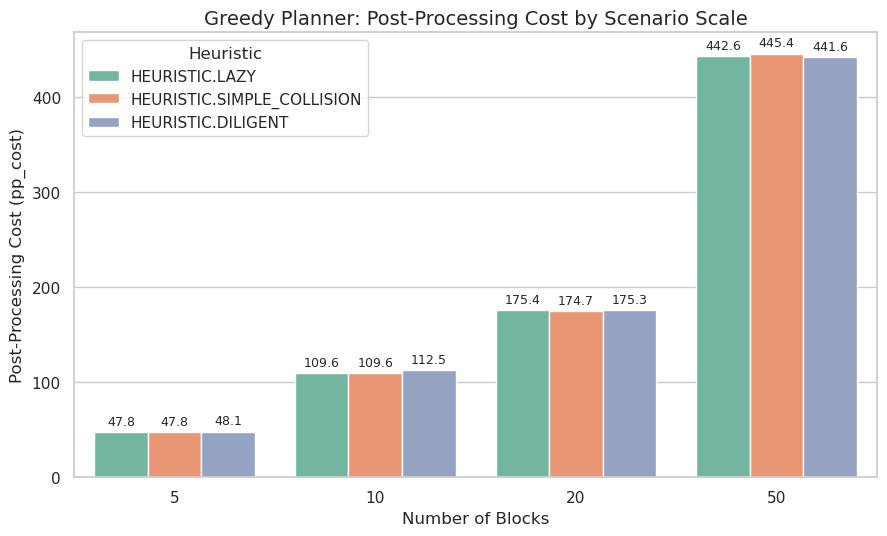

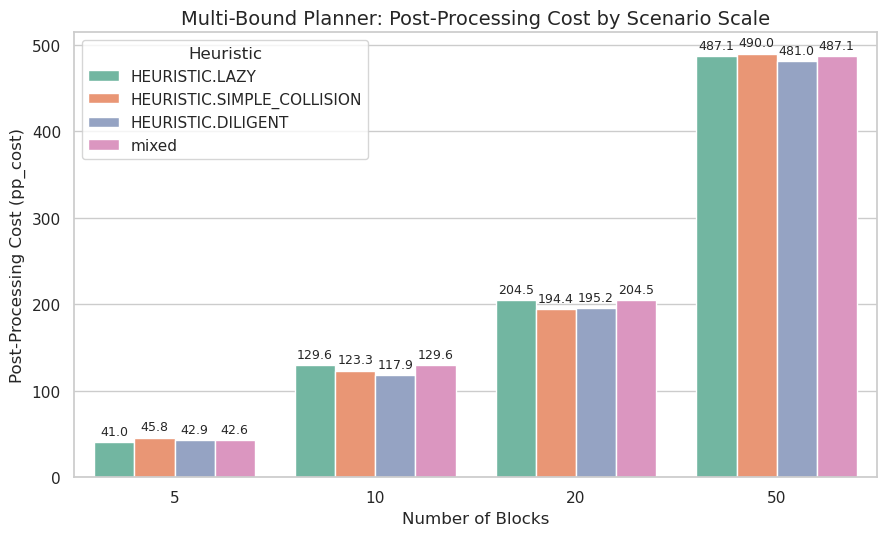

In [20]:
# ----------------- Figure 1: Greedy Planner Cost (Bar) -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_greedy, 
    x='no.blocks', 
    y='pp_cost', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Greedy Planner: Post-Processing Cost by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Post-Processing Cost (pp_cost)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper left')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()

# ----------------- Figure 2: Multi-Bound Planner Cost (Bar) -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_mb, 
    x='no.blocks', 
    y='pp_cost', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Multi-Bound Planner: Post-Processing Cost by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Post-Processing Cost (pp_cost)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper left')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()
plt.show()

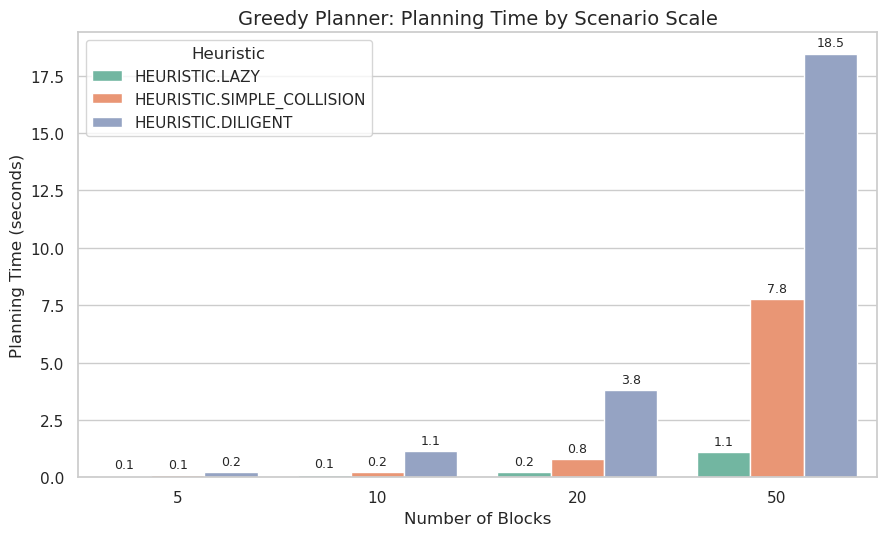

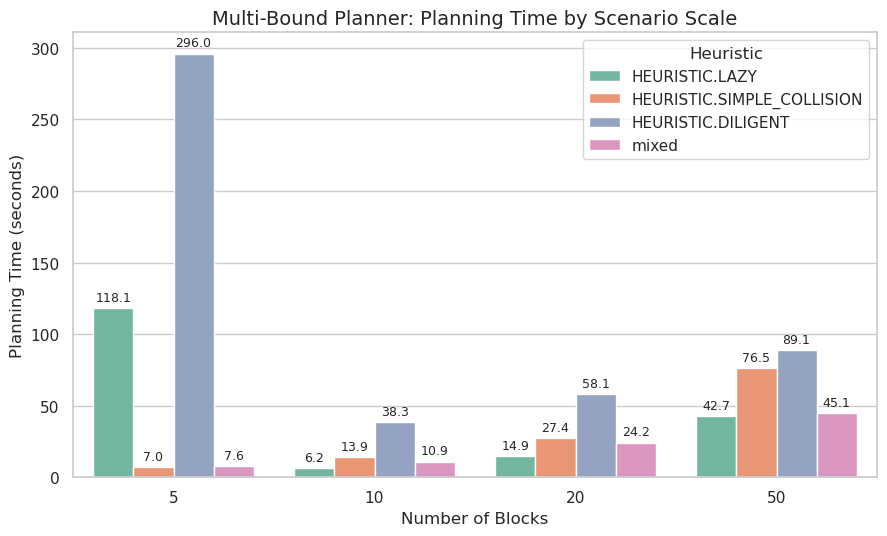

In [22]:
# ----------------- Figure 3: Greedy Planner Execution Time -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_greedy, 
    x='no.blocks', 
    y='planning_time', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Greedy Planner: Planning Time by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Planning Time (seconds)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper left')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()

# ----------------- Figure 4: Multi-Bound Planner Execution Time -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_mb, 
    x='no.blocks', 
    y='planning_time', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Multi-Bound Planner: Planning Time by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Planning Time (seconds)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper right')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()
plt.show()

In [43]:
cost_files = glob.glob("../results/*_mb_costs.csv")
print(f"Found files: {cost_files}")

all_dfs = []
all_filtered_dfs = []
window_size = 50
for file in cost_files:
    # Extract the number of blocks from the filename (e.g., '5_multi_bound_mb_costs.csv' -> 5)
    df_temp = pd.read_csv(file)

    # Create an iteration counter per heuristic group
    df_temp['iteration'] = df_temp.groupby('heuristic').cumcount() + 1

    # Calculate running minimum (subsequently decreasing costs) per heuristic group
    df_temp['running_min_cost'] = df_temp.groupby('heuristic')['mb_cost_per_iteration'].cummin() # Wait, check if lower is better!

    # 2. Calculate Moving Average per heuristic group
    # Using min_periods=1 ensures we get values for the very first iterations instead of NaNs
    df_temp['smoothed_cost'] = df_temp.groupby('heuristic')['mb_cost_per_iteration'].transform(
        lambda x: x.rolling(window=window_size, min_periods=1).mean()
    )
    
    all_dfs.append(df_temp)

    df_decreasing = df_temp.drop_duplicates(subset=['heuristic', 'running_min_cost'], keep='first').copy()
    all_filtered_dfs.append(df_decreasing)
    all_dfs.append(df_temp)

df_costs = pd.concat(all_dfs, ignore_index=True)
df_filtered_all = pd.concat(all_filtered_dfs, ignore_index=True)

Found files: ['../results/20_multi_bound_mb_costs.csv', '../results/10_multi_bound_mb_costs.csv', '../results/5_multi_bound_mb_costs.csv', '../results/50_multi_bound_mb_costs.csv']


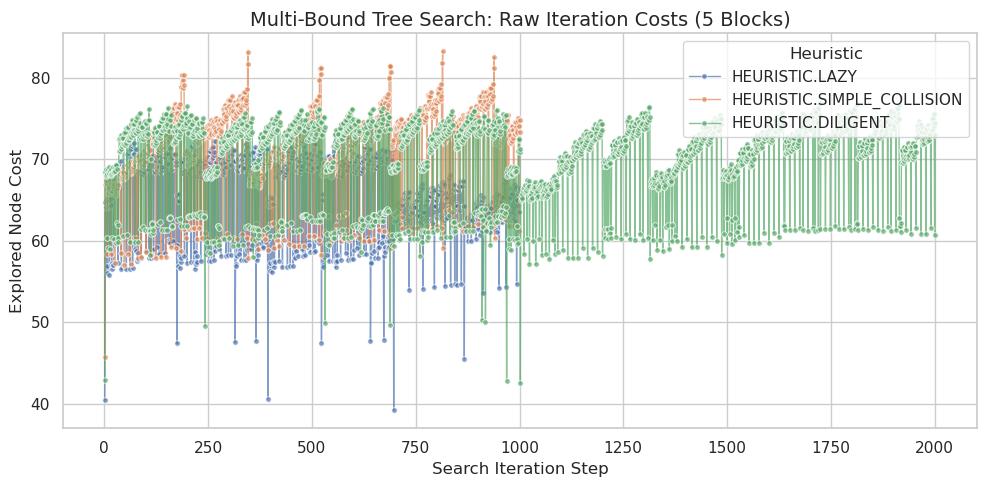

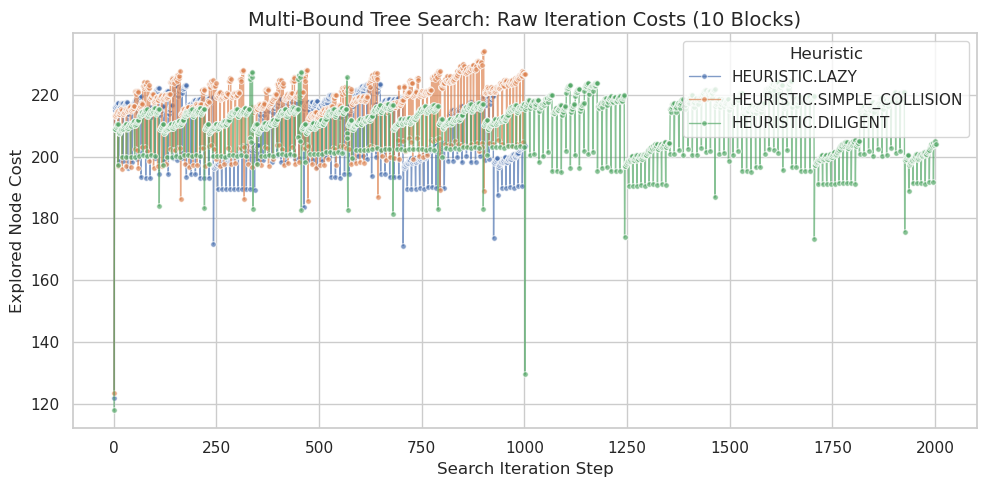

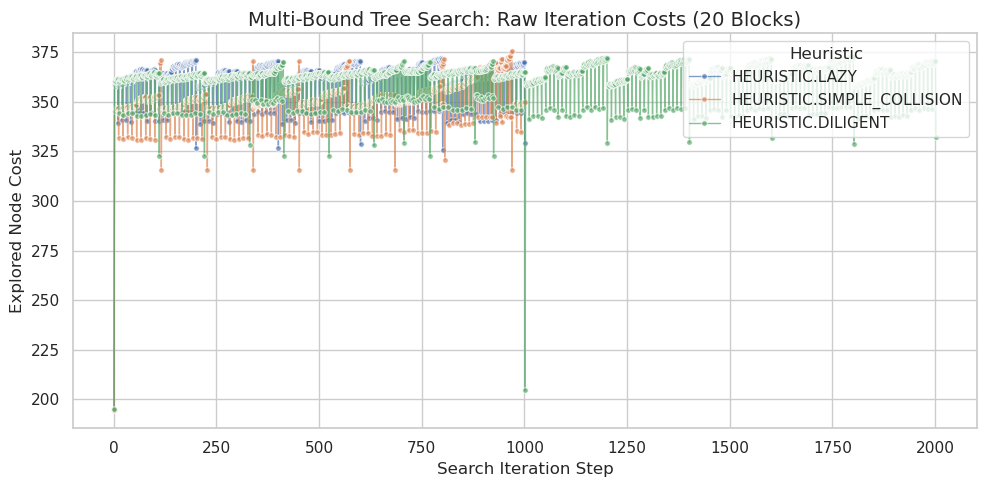

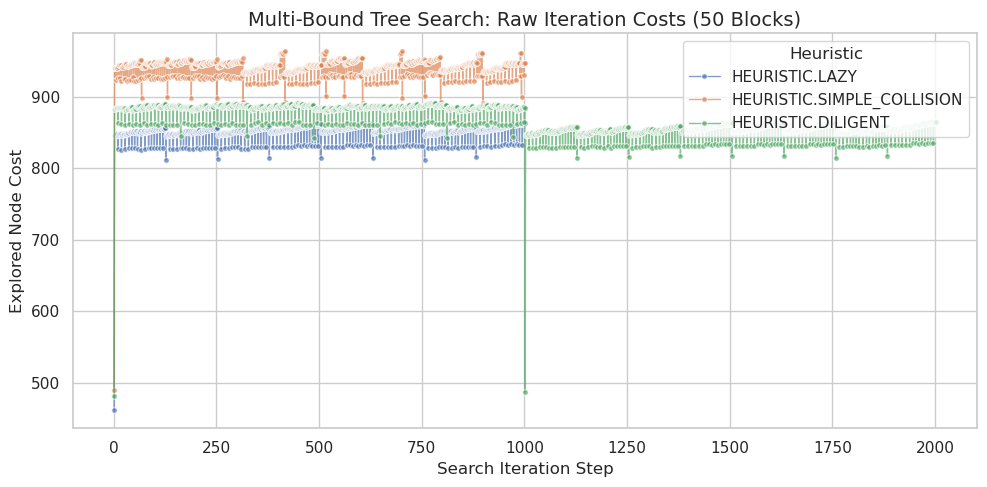

In [32]:
# Create distinct figures based on scenario scale
unique_scales = sorted(df_costs['no.blocks'].unique())

for scale in unique_scales:
    df_scale = df_costs[df_costs['no.blocks'] == scale]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot line with scatter points markers
    sns.lineplot(
        data=df_scale,
        x='iteration',
        y='mb_cost_per_iteration',
        hue='heuristic',
        marker='o',
        linewidth=1,
        markersize=4,
        alpha=0.7,
        ax=ax
    )

    ax.set_title(f'Multi-Bound Tree Search: Raw Iteration Costs ({scale} Blocks)')
    ax.set_xlabel('Search Iteration Step')
    ax.set_ylabel('Explored Node Cost')
    ax.legend(title='Heuristic', loc='upper right')
    
    plt.tight_layout()
plt.show()

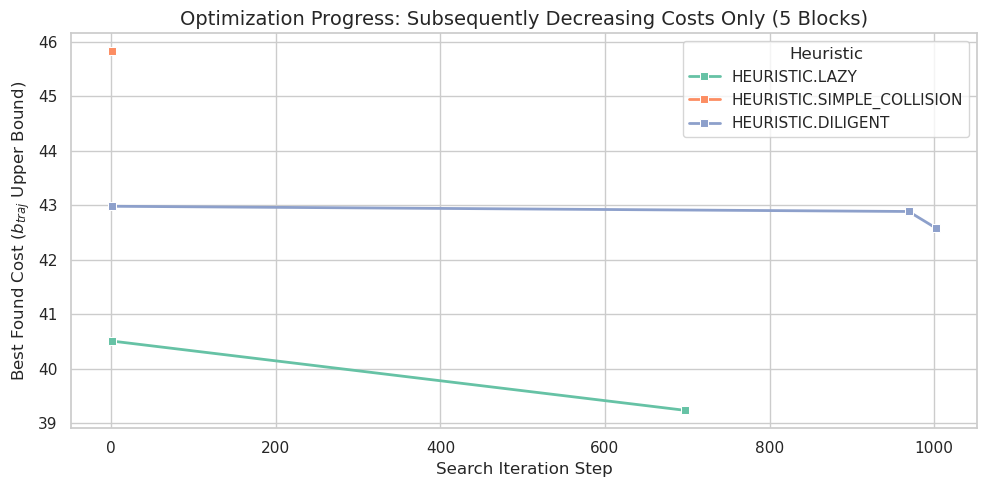

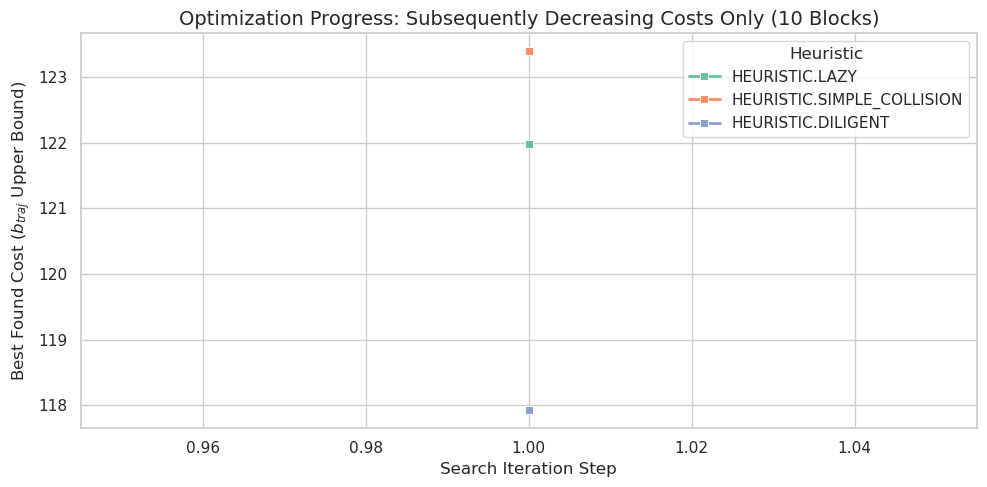

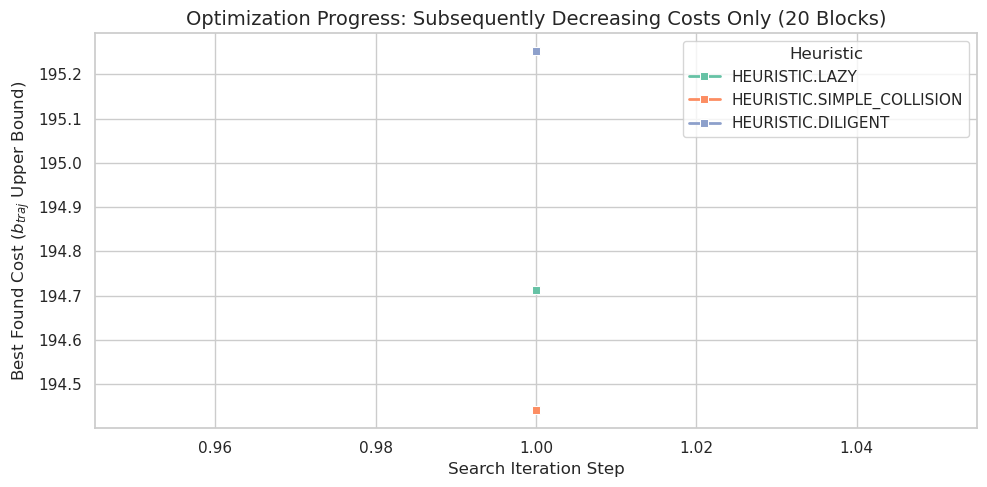

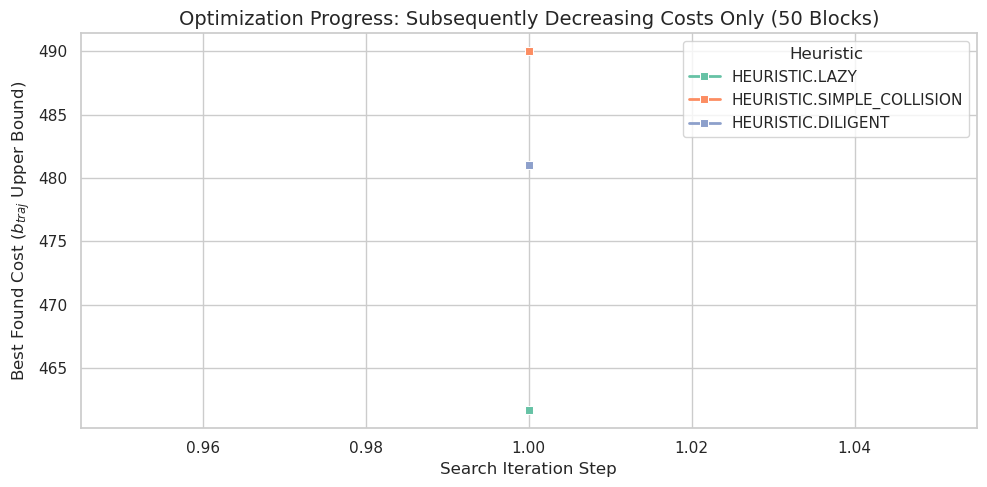

In [41]:
for scale in unique_scales:
    df_scale = df_filtered_all[df_filtered_all['no.blocks'] == scale]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(
        data=df_scale,
        x='iteration',
        y='mb_cost_per_iteration',
        hue='heuristic',
        palette=heuristic_colors,
        marker='s',  # Square markers for breakthrough moments
        linewidth=2,
        markersize=6,
        ax=ax
    )

    ax.set_title(f'Optimization Progress: Subsequently Decreasing Costs Only ({scale} Blocks)')
    ax.set_xlabel('Search Iteration Step')
    ax.set_ylabel('Best Found Cost ($b_{traj}$ Upper Bound)')
    ax.legend(title='Heuristic', loc='upper right')  # Placed top-left inside grid

    plt.tight_layout()
    plt.show()

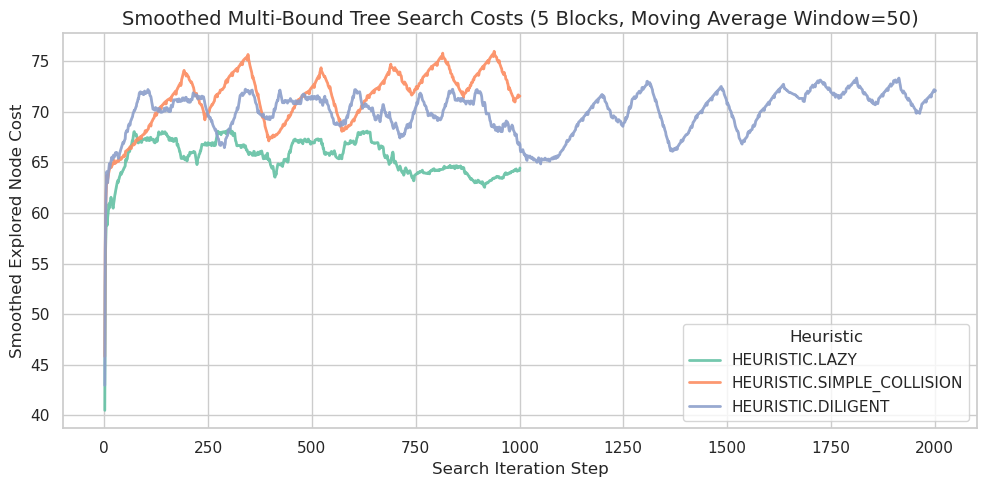

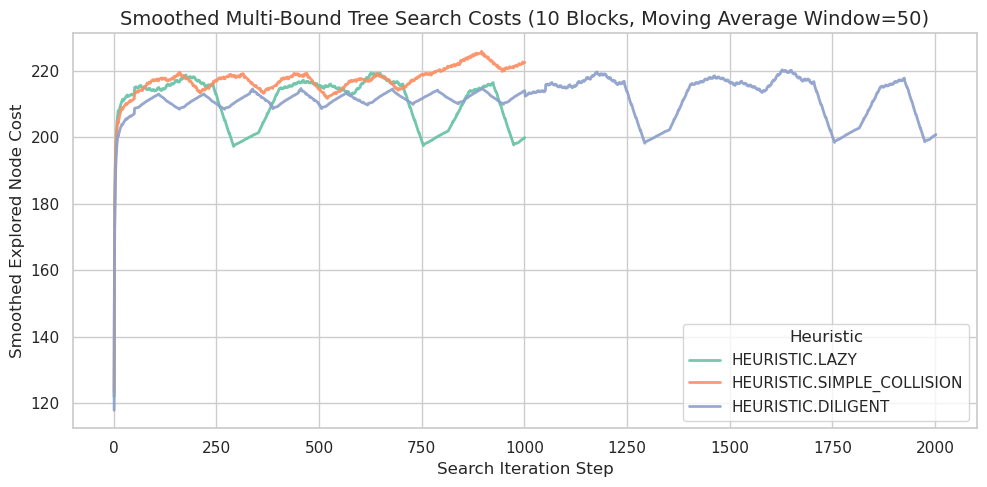

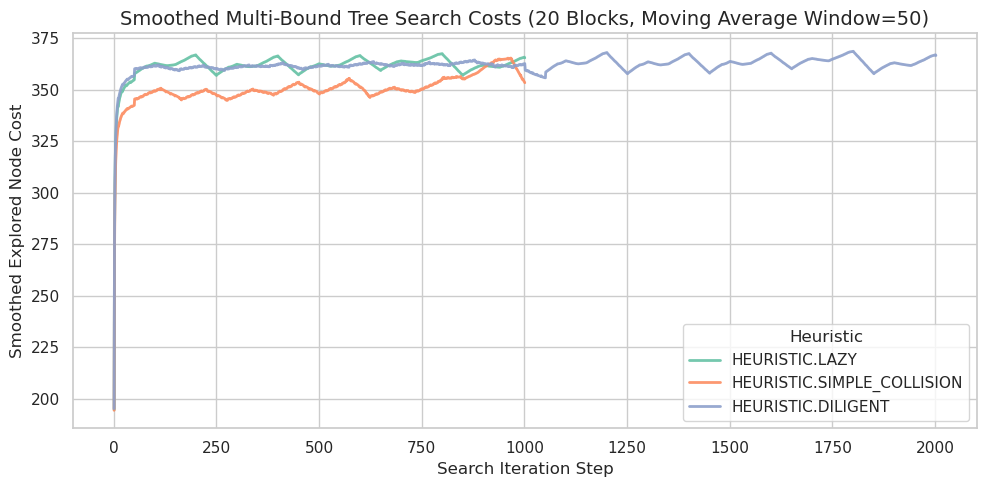

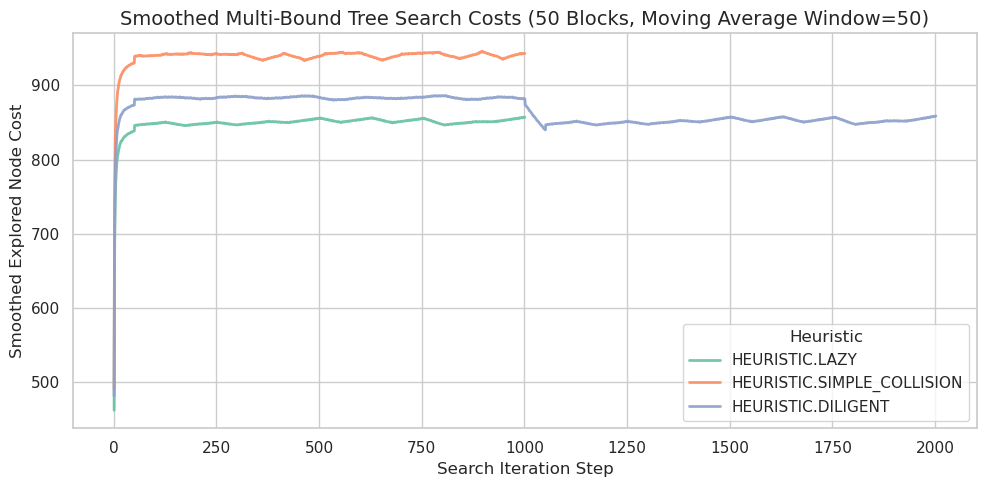

In [45]:
unique_scales = sorted(df_costs['no.blocks'].unique())

for scale in unique_scales:
    df_scale = df_costs[df_costs['no.blocks'] == scale]

    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot the smoothed trendline
    sns.lineplot(
        data=df_scale,
        x='iteration',
        y='smoothed_cost',
        hue='heuristic',
        palette=heuristic_colors,
        marker=None,       # Removed scatter points to emphasize the clean smooth curve
        linewidth=2,       # Thicker line for better visibility
        alpha=0.9,
        ax=ax
    )

    ax.set_title(f'Smoothed Multi-Bound Tree Search Costs ({scale} Blocks, Moving Average Window={window_size})')
    ax.set_xlabel('Search Iteration Step')
    ax.set_ylabel('Smoothed Explored Node Cost')
    ax.legend(title='Heuristic', loc='lower right')  # Legend in top-left corner

    plt.tight_layout()
    plt.savefig(f'{scale}_blocks_smoothed_iterations.png', dpi=300)
    plt.show()